# **Project Title: Predicting divorce**
by Kabir, Rodrigue and Sertac

**Research main objective**

This project aims to develop and validate predictive models of divorce using multidimensional determinants (demographic, socioeconomic, relational, and psychological characteristics), and to identify the key factors that most strongly contribute to marital dissolution. 

Specifically, it seeks at 

-	Training and comparing multiple supervised learning models predicting divorce
-	Identifiy the most important predictors of divorce


**Research questions**

- Which supervised machine-learning model and deep learning models offers the most reliable and robust prediction of divorce?
-	Which factors contribute most to predicting divorce ?


**Methods**
-	Exploration of the dataset 
-	Preparation of the dataset
-	Training and comparison of supervised learning models
-	Identification of  the most important predictors of divorce


In [1]:
#Load libraries that will be used throughout the project (will be continuouysly updated)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load the dataset
df = pd.read_csv('divorce_df.csv')
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [3]:
# Make a copy of the original dataset
df1 = df.copy()
df1.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [4]:
#Show the list of columns in the dataset
df1.columns

Index(['age_at_marriage', 'marriage_duration_years', 'num_children',
       'education_level', 'employment_status', 'combined_income',
       'religious_compatibility', 'cultural_background_match',
       'communication_score', 'conflict_frequency',
       'conflict_resolution_style', 'financial_stress_level',
       'mental_health_issues', 'infidelity_occurred', 'counseling_attended',
       'social_support', 'shared_hobbies_count', 'marriage_type',
       'pre_marital_cohabitation', 'domestic_violence_history', 'trust_score',
       'divorced'],
      dtype='object')

In [5]:
#Extract the dataset to be used for the project
df3 = df1.copy()
df3 = df1[['communication_score', 'financial_stress_level', 'mental_health_issues', 'infidelity_occurred', 'social_support', 'domestic_violence_history', 'trust_score', 'divorced']].copy()
df3.head()

,communication_score,financial_stress_level,mental_health_issues,infidelity_occurred,social_support,domestic_violence_history,trust_score,divorced
0,5.536016,6.026355,No,No,8.428183,No,6.262411,1
1,5.810172,1.000000,No,Yes,5.297221,No,6.769384,1
2,6.088146,3.199275,No,No,5.887066,No,5.532866,1
3,6.212046,4.893633,No,No,5.263555,No,3.491264,0
4,4.826262,9.431154,No,No,5.771259,No,10.000000,1


In [6]:
# Produce summary statistics of the dataset
df3.describe()

,communication_score,financial_stress_level,social_support,trust_score,divorced
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,6.040507,5.071450,5.966853,6.030525,0.398200
std,1.963349,2.326322,1.965504,1.932922,0.489576
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,4.661929,3.365562,4.597007,4.702663,0.000000
50%,6.058246,5.062464,6.010716,6.034343,0.000000
75%,7.426862,6.717954,7.328916,7.372830,1.000000
max,10.000000,10.000000,10.000000,10.000000,1.000000


In [7]:
# Generating frequency tables for binary variables
binary_columns = ['infidelity_occurred', 'domestic_violence_history', 'divorced', "mental_health_issues"]
for col in binary_columns:
    print(f"Frequency table for {col}:")
    print(df3[col].value_counts())
    print("\n")

Frequency table for infidelity_occurred:
infidelity_occurred
No     4255
Yes     745
Name: count, dtype: int64


Frequency table for domestic_violence_history:
domestic_violence_history
No     4748
Yes     252
Name: count, dtype: int64


Frequency table for divorced:
divorced
0    3009
1    1991
Name: count, dtype: int64


Frequency table for mental_health_issues:
mental_health_issues
No     3981
Yes    1019
Name: count, dtype: int64




In [8]:
# Check for missing values
df3.isnull().sum()

communication_score          0
financial_stress_level       0
mental_health_issues         0
infidelity_occurred          0
social_support               0
domestic_violence_history    0
trust_score                  0
divorced                     0
dtype: int64

**Pre-processing and preparation of the dataset for machine learning**

In [26]:
# Make train-test split
# Define feature matrix X and target vector y
X = df3[['communication_score', 'financial_stress_level', 'mental_health_issues', 'infidelity_occurred', 'social_support', 'domestic_violence_history', 'trust_score']]
y = df3['divorced']

# 2. Perform 80/20 train-test split 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print(f"--- Dataset Split Results ---")
print(f"Total samples: {len(df3)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")
print(f"-----------------------------")

--- Dataset Split Results ---
Total samples: 5000
X_train shape: (4000, 7)
X_test shape: (1000, 7)
y_train distribution:
divorced
0    0.604
1    0.396
Name: proportion, dtype: float64
y_test distribution:
divorced
0    0.593
1    0.407
Name: proportion, dtype: float64
-----------------------------


In [27]:
# 2. Preprocessing for numerical and categorical features
numerical_features = ["communication_score", "financial_stress_level", "social_support", "trust_score"]
categorical_features = ["mental_health_issues", "infidelity_occurred", "domestic_violence_history"]
numerical_transformer = StandardScaler() # Scale continuous features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Convert categorical features to numerical

# 3. Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


**Training and comparison of supervised models**

Model1: Logistic Regression

In [28]:
# Create preprocessing and modeling pipeline for logistic regression
divorce_model1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1))
])


--- Training Model (Logistic Regression Classifier) ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level mental_health_issues  \
0             5.536016                6.026355                   No   
1             5.810172                1.000000                   No   
2             6.088146                3.199275                   No   
3             6.212046                4.893633                   No   
4             4.826262                9.431154                   No   

  infidelity_occurred  social_support domestic_violence_history  trust_score  
0                  No        8.428183                        No     6.262411  
1                 Yes        5.297221                        No     6.769384  
2                  No        5.887066                        No     5.532866  
3                  No        5.263555                        No     3.491264  
4                  No        5.771259                        No    10.000

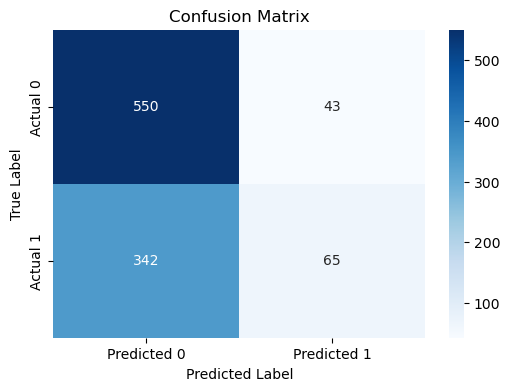


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.93      0.74       593
           1       0.60      0.16      0.25       407

    accuracy                           0.61      1000
   macro avg       0.61      0.54      0.50      1000
weighted avg       0.61      0.61      0.54      1000



In [29]:
# Define divorce_model1 (Logistic Regression)
divorce_model1 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(random_state=1))])
# Train the model
divorce_model1.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model1.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Logistic Regression Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model1.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))




--- Feature Importance (Logistic Regression) ---
                         Feature  Coefficient
9  domestic_violence_history_Yes     0.372830
8   domestic_violence_history_No    -0.332019
7        infidelity_occurred_Yes     0.237263
6         infidelity_occurred_No    -0.196452
0            communication_score    -0.149965
5       mental_health_issues_Yes     0.126283
3                    trust_score    -0.123986
1         financial_stress_level     0.123813
4        mental_health_issues_No    -0.085472
2                 social_support    -0.066463


C:\Users\kabir\AppData\Local\Temp\ipykernel_22188\1355294451.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


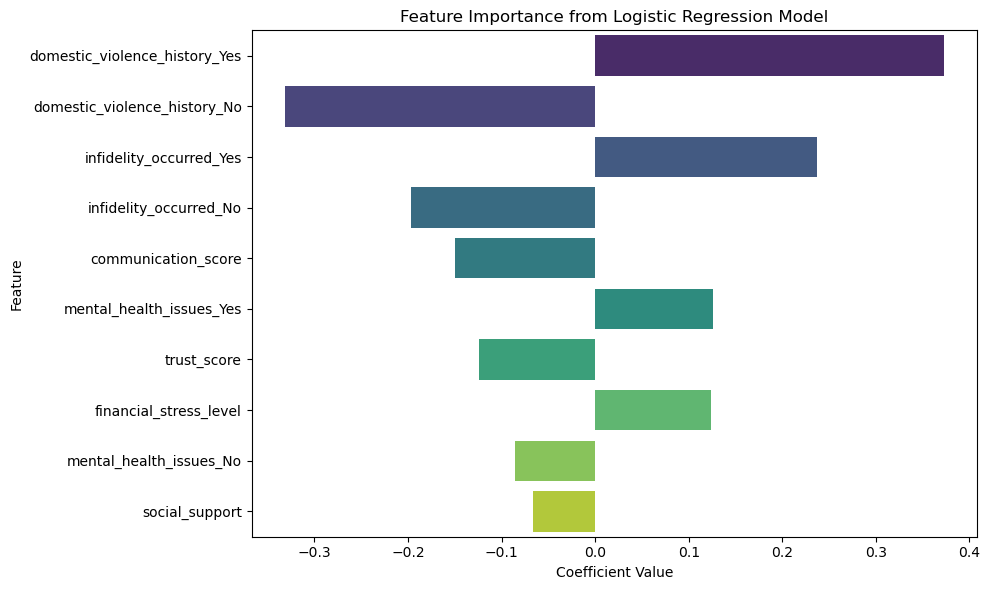

In [30]:
# Feature importance for logistic regression model
logistic_model = divorce_model1.named_steps['classifier']
feature_names_num = numerical_features
feature_names_cat = divorce_model1.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = feature_names_num + feature_names_cat
coefficients = logistic_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False).drop(columns='Absolute_Coefficient')
print("\n--- Feature Importance (Logistic Regression) ---")
print(feature_importance)

# plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance from Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Model2: Random Forest Classifier

In [31]:
# Create preprocessing and modeling pipeline for Random Forest Classifier
divorce_model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1))
])


--- Training Model (Random Forest Classifier) ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level mental_health_issues  \
0             5.536016                6.026355                   No   
1             5.810172                1.000000                   No   
2             6.088146                3.199275                   No   
3             6.212046                4.893633                   No   
4             4.826262                9.431154                   No   

  infidelity_occurred  social_support domestic_violence_history  trust_score  
0                  No        8.428183                        No     6.262411  
1                 Yes        5.297221                        No     6.769384  
2                  No        5.887066                        No     5.532866  
3                  No        5.263555                        No     3.491264  
4                  No        5.771259                        No    10.000000  


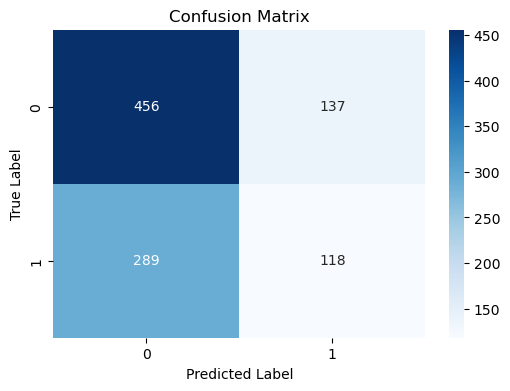


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.77      0.68       593
           1       0.46      0.29      0.36       407

    accuracy                           0.57      1000
   macro avg       0.54      0.53      0.52      1000
weighted avg       0.55      0.57      0.55      1000



In [32]:
# Define divorce_model2 (Random Forest Classifier)
divorce_model2 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42))])
# Train the model
divorce_model2.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model2.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Random Forest Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model2.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Feature Importance (Random Forest) ---
                         Feature  Importance
0            communication_score    0.245446
3                    trust_score    0.242892
2                 social_support    0.241028
1         financial_stress_level    0.234656
5       mental_health_issues_Yes    0.007688
4        mental_health_issues_No    0.007343
6         infidelity_occurred_No    0.005842
7        infidelity_occurred_Yes    0.005430
9  domestic_violence_history_Yes    0.005035
8   domestic_violence_history_No    0.004640


C:\Users\kabir\AppData\Local\Temp\ipykernel_22188\175498129.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


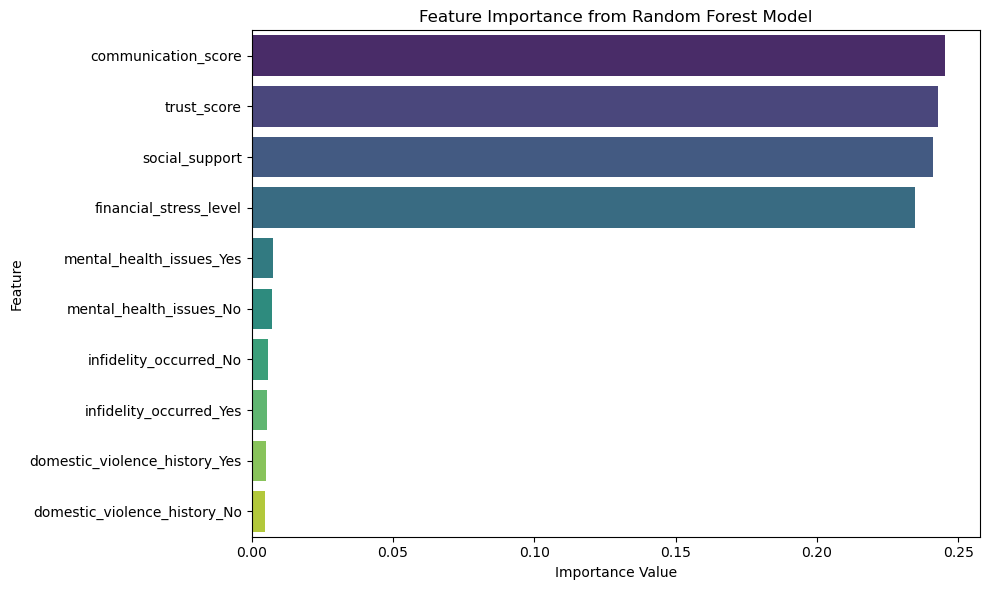

In [33]:
# Estimate feature importance for Random Forest model
random_forest_model = divorce_model2.named_steps['classifier']
feature_names_num = numerical_features
feature_names_cat = divorce_model2.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = feature_names_num + feature_names_cat
importances = random_forest_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\n--- Feature Importance (Random Forest) ---")
print(feature_importance)
# plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Model3: XGBoost Classifier

In [34]:
# Create preprocessing and modeling pipeline for XGBoost Classifier
divorce_model3 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier())
])


--- Training Model (XGBoost Classifier) ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level mental_health_issues  \
0             5.536016                6.026355                   No   
1             5.810172                1.000000                   No   
2             6.088146                3.199275                   No   
3             6.212046                4.893633                   No   
4             4.826262                9.431154                   No   

  infidelity_occurred  social_support domestic_violence_history  trust_score  
0                  No        8.428183                        No     6.262411  
1                 Yes        5.297221                        No     6.769384  
2                  No        5.887066                        No     5.532866  
3                  No        5.263555                        No     3.491264  
4                  No        5.771259                        No    10.000000  
The pr

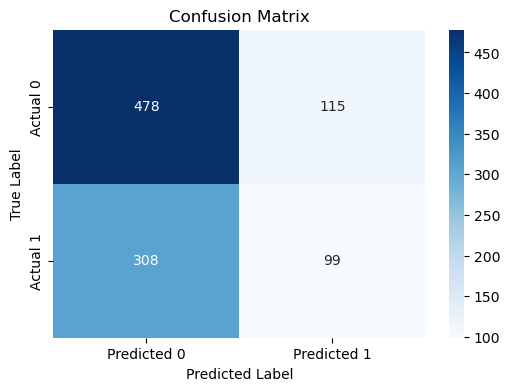


Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.81      0.69       593
           1       0.46      0.24      0.32       407

    accuracy                           0.58      1000
   macro avg       0.54      0.52      0.51      1000
weighted avg       0.55      0.58      0.54      1000



In [35]:
# Define divorce_model3 (Xgboost Classifier)
divorce_model3 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', XGBClassifier(n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'))])
# Train the model
divorce_model3.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model3.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (XGBoost Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model3.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Feature Importance (XGBoost) ---
                         Feature  Importance
9  domestic_violence_history_Yes    0.175536
8   domestic_violence_history_No    0.132060
7        infidelity_occurred_Yes    0.114331
6         infidelity_occurred_No    0.101563
1         financial_stress_level    0.083594
5       mental_health_issues_Yes    0.083028
0            communication_score    0.079952
2                 social_support    0.078433
3                    trust_score    0.077099
4        mental_health_issues_No    0.074404


C:\Users\kabir\AppData\Local\Temp\ipykernel_22188\707886772.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


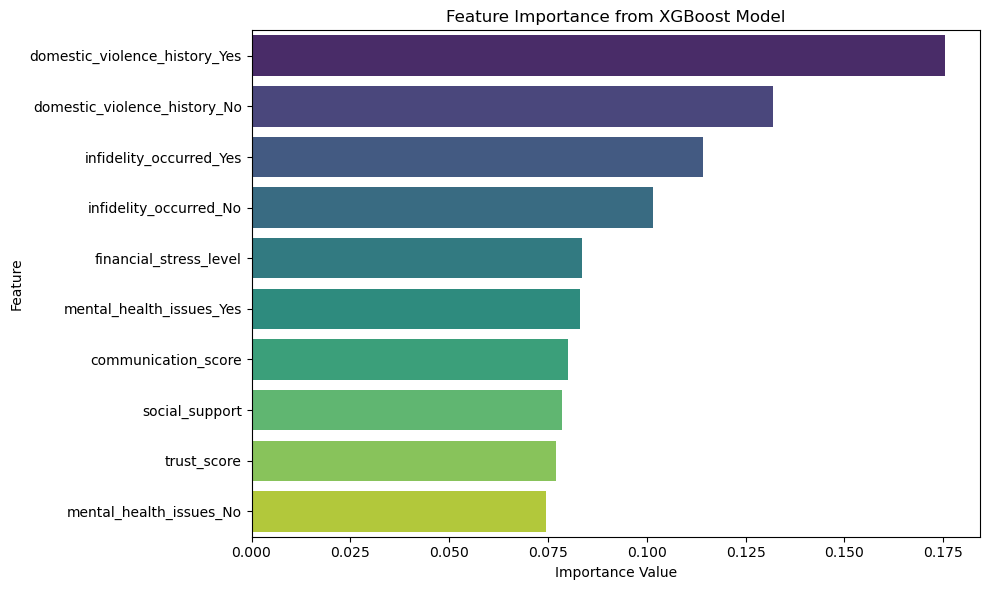

In [36]:
# Estimate feature importance for xgboost model
xgb_model = divorce_model3.named_steps['classifier']
feature_names_num = numerical_features
feature_names_cat = divorce_model3.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = feature_names_num + feature_names_cat
importances = xgb_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\n--- Feature Importance (XGBoost) ---")
print(feature_importance)
# plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance from XGBoost Model')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Deep Learning**

In [37]:
df1 = df[['communication_score', 'financial_stress_level', 
          'mental_health_issues', 'infidelity_occurred', 
          'social_support', 'domestic_violence_history', 
          'trust_score', 'divorced']].copy()

# Convert Yes/No to 1/0
binary_cols = ['mental_health_issues', 'infidelity_occurred', 'domestic_violence_history']

for col in binary_cols:
    df1[col] = df1[col].map({'Yes': 1, 'No': 0})
# Split
X = df1.drop('divorced', axis=1)
y = df1['divorced']


In [38]:
#Neural Network

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [39]:
# train test split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Further split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_nn, y_train_nn, test_size=0.2, random_state=42
)

In [40]:
#Converting PyTorch to Tensor
X_train_nn = torch.FloatTensor(X_train_nn)
X_test_nn = torch.FloatTensor(X_test_nn)
y_train_nn = torch.FloatTensor(y_train_nn.values).unsqueeze(1)
y_test_nn = torch.FloatTensor(y_test_nn.values).unsqueeze(1)



In [41]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)

In [42]:
# Deep Feed Forward Neural Network
class DivorceModel(nn.Module):
    def __init__(self, input_dim):
        super(DivorceModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 32)
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
        self.ReLU = nn.ReLU()

    def forward(self, x):
        x = self.ReLU(self.layer1(x))
        x = self.ReLU(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x
model = DivorceModel(X_train_nn.shape[1])

In [43]:
#Loss & Optimizer

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    val_losses.append(val_loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss:.4f}, Val Loss: {val_loss:.4f}')

Epoch [10/100], Train Loss: 0.7097, Val Loss: 0.7077
Epoch [20/100], Train Loss: 0.6923, Val Loss: 0.6903
Epoch [30/100], Train Loss: 0.6783, Val Loss: 0.6771
Epoch [40/100], Train Loss: 0.6689, Val Loss: 0.6691
Epoch [50/100], Train Loss: 0.6641, Val Loss: 0.6656
Epoch [60/100], Train Loss: 0.6616, Val Loss: 0.6640
Epoch [70/100], Train Loss: 0.6598, Val Loss: 0.6632
Epoch [80/100], Train Loss: 0.6584, Val Loss: 0.6631
Epoch [90/100], Train Loss: 0.6574, Val Loss: 0.6632
Epoch [100/100], Train Loss: 0.6566, Val Loss: 0.6634


In [45]:
#Test Accuracy
with torch.no_grad():
    y_pred_test= model(X_test_nn)
    y_pred_label = (y_pred_test > 0.5).float()

    accuracy = (y_pred_label.numpy() == y_test_nn).sum() / y_test_nn.shape[0]
    print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.6110000014305115



--- Deep Feed Forward Neural Network Model ---
Making predictions for the following 5 couples:
   communication_score  financial_stress_level  mental_health_issues  \
0             5.536016                6.026355                     0   
1             5.810172                1.000000                     0   
2             6.088146                3.199275                     0   
3             6.212046                4.893633                     0   
4             4.826262                9.431154                     0   

   infidelity_occurred  social_support  domestic_violence_history  trust_score  
0                    0        8.428183                          0     6.262411  
1                    1        5.297221                          0     6.769384  
2                    0        5.887066                          0     5.532866  
3                    0        5.263555                          0     3.491264  
4                    0        5.771259                          0 

<Figure size 600x400 with 0 Axes>

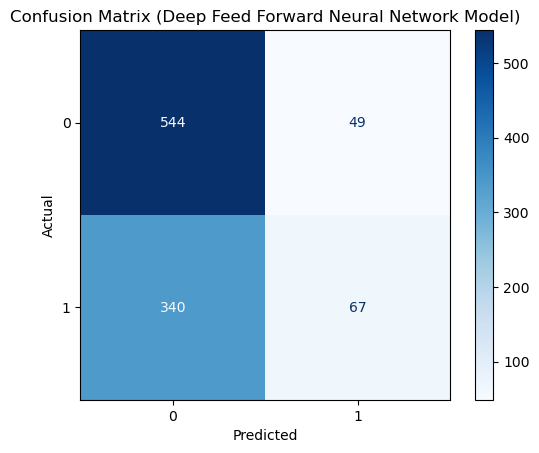


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.92      0.74       593
           1       0.58      0.16      0.26       407

    accuracy                           0.61      1000
   macro avg       0.60      0.54      0.50      1000
weighted avg       0.60      0.61      0.54      1000



In [46]:
cm = confusion_matrix(y_test_nn.numpy(), y_pred_label.numpy())

print("\n--- Deep Feed Forward Neural Network Model ---")

print("Making predictions for the following 5 couples:")
sample_data = X.head().copy()
# X already contains numeric 0/1 values for the binary features, so no remapping is required
sample_scaled = scaler.transform(sample_data)
sample_tensor = torch.FloatTensor(sample_scaled)
with torch.no_grad():
    predictions = model(sample_tensor)
    predictions_binary = (predictions > 0.5).float().numpy().flatten()
print(sample_data)
print("The predictions are (0: Not Divorced, 1: Divorced)")
print(predictions_binary)

# Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
plt.figure(figsize=(6, 4))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Deep Feed Forward Neural Network Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Accuracy, Precision, Recall, F1 Score
print("\nClassification Report:")
print(classification_report(y_test_nn.numpy(), y_pred_label.numpy(), target_names=["0", "1"]))

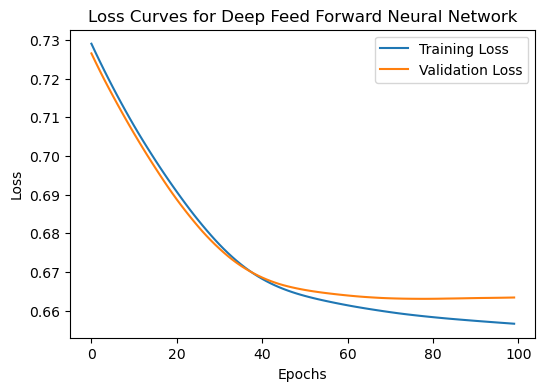

In [47]:
# Loss curve visualization
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Curves for Deep Feed Forward Neural Network')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**ROC-AUC Curve(Model Performance)**

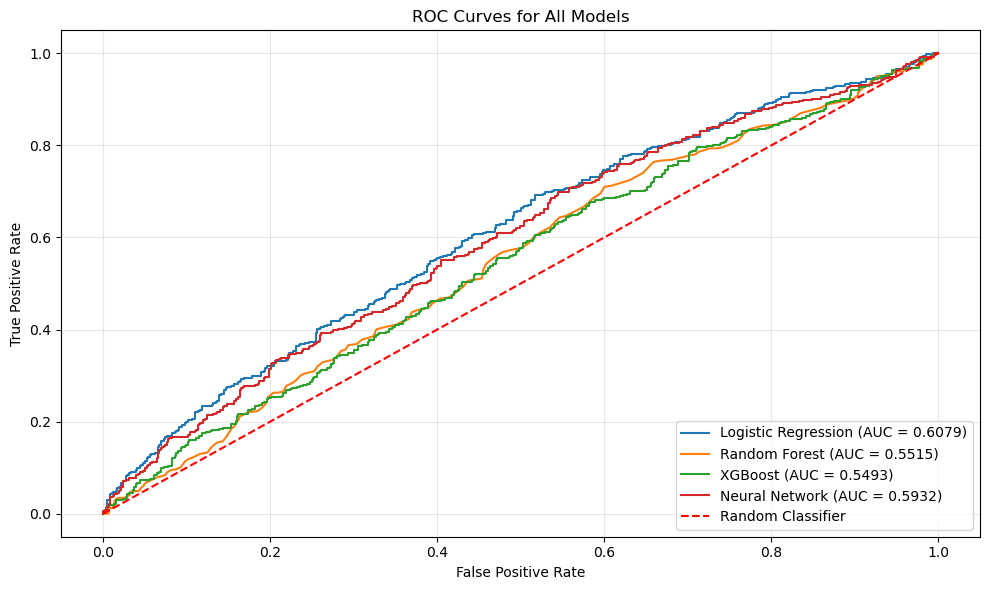


--- Model Performance Comparison ---
                 Model   ROC-AUC  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.607903     0.615   0.601852  0.159705  0.252427
1        Random Forest  0.551506     0.574   0.462745  0.289926  0.356495
2              XGBoost  0.549271     0.577   0.462617  0.243243  0.318841
3       Neural Network  0.593190     0.611   0.577586  0.164619  0.256214


In [50]:
# Preparing data for model comparison
# X_train and X_test are already DataFrames from sklearn train_test_split
# y_train and y_test are already Series from sklearn train_test_split



# Models to be compared: Logistic Regression, Random Forest, XGBoost, Deep Learning (Neural Network)
logreg_model = divorce_model1  # Logistic Regression model (already defined as 'pipeline')
rf_model = divorce_model2
xgb_model = divorce_model3     # XGBoost model (already defined)
dl_model = model               # Deep Learning model (Neural Network)
 
models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Neural Network": dl_model
}

# Evaluate each model and store results in a table
roc_table = []
plt.figure(figsize=(10, 6))

for name, current_model in models.items():
    if name == "Neural Network":
        # Use the neural network specific test data (tensor form)
        with torch.no_grad():
            y_score = dl_model(X_test_nn).detach().numpy().ravel()
            y_pred_label = (y_score > 0.5).astype(int)
    else:
        # Use sklearn predict_proba for other models
        y_score = current_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
        y_pred_label = current_model.predict(X_test)
      
    # Calculate metrics
    roc_auc = roc_auc_score(y_test, y_score)
    accuracy = accuracy_score(y_test, y_pred_label)
    precision = precision_score(y_test, y_pred_label)
    recall = recall_score(y_test, y_pred_label)
    f1 = f1_score(y_test, y_pred_label)
    
    roc_table.append({
        "Model": name,
        "ROC-AUC": roc_auc,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })  
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')   

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a DataFrame for the performance metrics
performance_df = pd.DataFrame(roc_table)
print("\n--- Model Performance Comparison ---")
print(performance_df)

**Feature Importance**

In [51]:
# Create validation set from the deep learning data
# Split the scaled data for feature importance analysis
X_train_split, X_val, y_train_split, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

C:\Users\kabir\AppData\Local\Temp\ipykernel_22188\2859740754.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


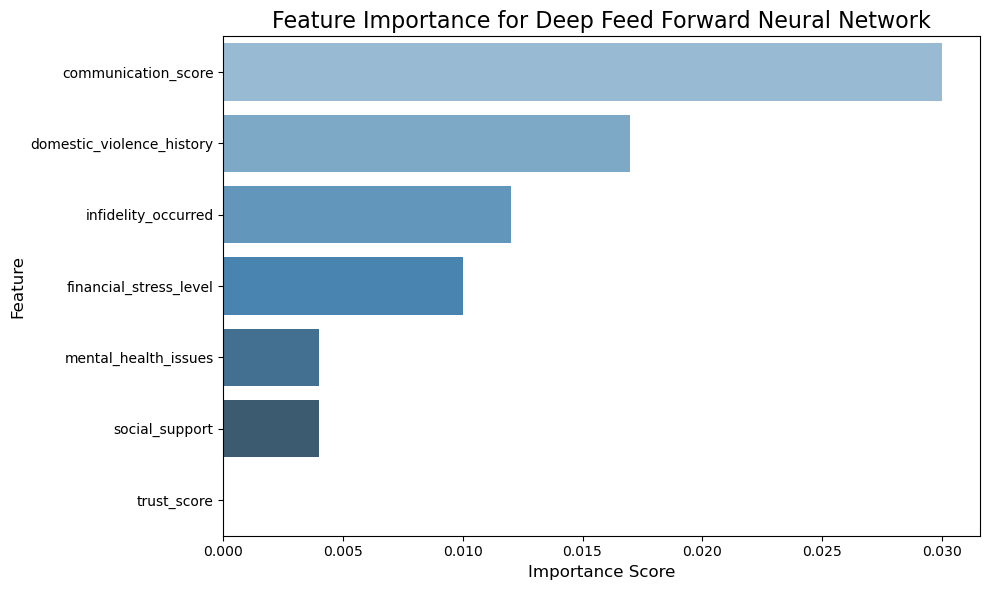


--- Feature Importance (Deep Feed Forward Neural Network) ---
                  Feature  Importance
      communication_score       0.030
domestic_violence_history       0.017
      infidelity_occurred       0.012
   financial_stress_level       0.010
     mental_health_issues       0.004
           social_support       0.004
              trust_score      -0.002


In [52]:
# Convert validation data to tensors (already scaled from X_scaled split)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_values = y_val.values if hasattr(y_val, 'values') else y_val

# Baseline prediction on validation set (accuracy-based permutation importance)
with torch.no_grad():
    baseline_preds = dl_model(X_val_tensor).detach().numpy().ravel()
    baseline_preds_binary = (baseline_preds > 0.5).astype(int)
baseline_accuracy = accuracy_score(y_val_values, baseline_preds_binary)

# Permutation importance using accuracy metric
importances = []
feature_names = X.columns.tolist()

for i, col in enumerate(feature_names):
    X_shuffled = X_val.copy()
    # Shuffle the i-th column
    X_shuffled[:, i] = np.random.permutation(X_shuffled[:, i])
    shuffled_tensor = torch.tensor(X_shuffled, dtype=torch.float32)
    
    with torch.no_grad():
        preds = dl_model(shuffled_tensor).detach().numpy().ravel()
        preds_binary = (preds > 0.5).astype(int)
    
    shuffled_accuracy = accuracy_score(y_val_values, preds_binary)
    # Importance = drop in accuracy when feature is shuffled
    importance_score = baseline_accuracy - shuffled_accuracy
    importances.append(importance_score)

# Create DataFrame for plotting
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    palette="Blues_d"
)
plt.title('Feature Importance for Deep Feed Forward Neural Network', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

print("\n--- Feature Importance (Deep Feed Forward Neural Network) ---")
print(feature_importance_df.to_string(index=False))